In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"GPU Count: {torch.cuda.device_count()}")

print("=" * 50)

# Mixed Precision Scaler
scaler = GradScaler(enabled=torch.cuda.is_available())

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version: 12.8
PyTorch Version: 2.11.0+cu128
GPU Count: 1


C:\Users\91905\AppData\Local\Temp\ipykernel_6712\2767945693.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())


In [3]:
TRAIN_DIR = "../data/raw/Lung_Disease_Dataset/train"
VAL_DIR = "../data/raw/Lung_Disease_Dataset/val"

MODEL_DIR = "../models/Transfer_1"
os.makedirs(MODEL_DIR, exist_ok=True)

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 35
EARLY_STOPPING_PATIENCE = 10

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=8,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        shear=3
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.06),
        ratio=(0.5, 2.0),
        value='random'
    ),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transforms
)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Classes ({len(train_dataset.classes)}):")
for idx, cls in enumerate(train_dataset.classes):
    print(f"  {idx}: {cls}")

print(f"\nTraining Samples  : {len(train_dataset):,}")
print(f"Validation Samples: {len(val_dataset):,}")

print("=" * 60)

Dataset Summary
Classes (5):
  0: Bacterial Pneumonia
  1: Corona Virus Disease
  2: Normal
  3: Tuberculosis
  4: Viral Pneumonia

Training Samples  : 6,054
Validation Samples: 2,016


In [7]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

In [8]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    drop_last=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

In [9]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

In [10]:
for param in model.features.parameters():
    param.requires_grad = False

In [11]:
# ============================================================
# Custom EfficientNet-B0 Classifier
# ============================================================

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(

    nn.Dropout(0.5),

    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),

    nn.Dropout(0.30),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),

    nn.Dropout(0.20),

    nn.Linear(256, NUM_CLASSES)

)

model = model.to(device)

In [12]:
# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# ============================================================
# Optimizer
# ============================================================

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
    eps=1e-8
)

# ============================================================
# Learning Rate Scheduler
# ============================================================

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print("=" * 60)
print("Training Configuration")
print("=" * 60)
print(f"Loss Function : CrossEntropyLoss (Label Smoothing = 0.1)")
print(f"Optimizer     : AdamW")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Weight Decay  : {WEIGHT_DECAY}")
print(f"Scheduler     : CosineAnnealingLR")
print("=" * 60)

Training Configuration
Loss Function : CrossEntropyLoss (Label Smoothing = 0.1)
Optimizer     : AdamW
Learning Rate : 0.0003
Weight Decay  : 0.0001
Scheduler     : CosineAnnealingLR


In [13]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel()
    for p in model.parameters()
    if not p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("=" * 60)
print("Model Summary")
print("=" * 60)
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Frozen Parameters    : {frozen_params:,}")
print(f"Total Parameters     : {total_params:,}")
print("=" * 60)

Model Summary
Trainable Parameters : 790,021
Frozen Parameters    : 4,007,548
Total Parameters     : 4,797,569


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=torch.cuda.is_available()):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient Clipping
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader)

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        acc,
        precision,
        recall,
        f1
    )

In [15]:
def validate(model, loader):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader, leave=False):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=torch.cuda.is_available()):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            all_preds.extend(
                preds.detach().cpu().numpy()
            )

            all_labels.extend(
                labels.detach().cpu().numpy()
            )

    epoch_loss = running_loss / len(loader)

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return (
        epoch_loss,
        acc,
        precision,
        recall,
        f1
    )

In [16]:
from copy import deepcopy

history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": [],

    "train_f1": [],
    "val_f1": [],

    "learning_rate": [],
    "medical_score": []
}

RECALL_WEIGHT = 0.60
F1_WEIGHT = 0.40

best_score = 0.0
best_epoch = 0

early_stop_counter = 0

best_model_path = os.path.join(
    MODEL_DIR,
    "efficientnet_head_best.pth"
)

best_model_weights = deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 70)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print("=" * 70)

    (
        train_loss,
        train_acc,
        train_precision,
        train_recall,
        train_f1
    ) = train_one_epoch(
        model,
        train_loader
    )

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = validate(
        model,
        val_loader
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    score = (
        RECALL_WEIGHT * val_recall +
        F1_WEIGHT * val_f1
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    history["train_precision"].append(train_precision)
    history["val_precision"].append(val_precision)

    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    history["learning_rate"].append(current_lr)
    history["medical_score"].append(score)

    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}")
    print(f"Train Precision : {train_precision:.4f}")
    print(f"Train Recall    : {train_recall:.4f}")
    print(f"Train F1        : {train_f1:.4f}")

    print("-" * 50)

    print(f"Val Loss        : {val_loss:.4f}")
    print(f"Val Accuracy    : {val_acc:.4f}")
    print(f"Val Precision   : {val_precision:.4f}")
    print(f"Val Recall      : {val_recall:.4f}")
    print(f"Val F1          : {val_f1:.4f}")

    print("-" * 50)

    print(f"Learning Rate   : {current_lr:.8f}")
    print(f"Medical Score   : {score:.4f}")

    if score > best_score:

        best_score = score
        best_epoch = epoch + 1

        early_stop_counter = 0

        best_model_weights = deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),

                "accuracy": val_acc,
                "precision": val_precision,
                "recall": val_recall,
                "f1": val_f1,
                "score": score,
            },
            best_model_path,
        )

        print(
            "\n✅ Best Model Saved!"
        )

        print(
            f"Best Score : {best_score:.4f}"
        )

    else:

        early_stop_counter += 1

        print(
            f"\nEarly Stopping Counter : "
            f"{early_stop_counter}/{EARLY_STOPPING_PATIENCE}"
        )

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n🛑 Early Stopping Triggered!")

        break


# ============================================================
# Load Best Model
# ============================================================

model.load_state_dict(best_model_weights)

# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(MODEL_DIR, "training_history.csv"),
    index=False
)

# ============================================================
# Training Summary
# ============================================================

print("\n" + "=" * 70)

print("Training Completed!")

print("=" * 70)

print(f"Best Epoch          : {best_epoch}")

print(f"Best Medical Score  : {best_score:.4f}")

print(f"Best Model Saved At : {best_model_path}")

print(
    os.path.join(
        MODEL_DIR,
        "training_history.csv"
    )
)


Epoch [1/35]


  0%|          | 0/189 [00:00<?, ?it/s]C:\Users\91905\AppData\Local\Temp\ipykernel_6712\1619704729.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
  0%|          | 0/63 [00:00<?, ?it/s]              C:\Users\91905\AppData\Local\Temp\ipykernel_6712\4109156254.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Train Loss      : 1.0500
Train Accuracy  : 0.6481
Train Precision : 0.6446
Train Recall    : 0.6476
Train F1        : 0.6435
--------------------------------------------------
Val Loss        : 0.8182
Val Accuracy    : 0.7708
Val Precision   : 0.7745
Val Recall      : 0.7703
Val F1          : 0.7642
--------------------------------------------------
Learning Rate   : 0.00029940
Medical Score   : 0.7678

✅ Best Model Saved!
Best Score : 0.7678

Epoch [2/35]


  0%|          | 0/189 [00:00<?, ?it/s]C:\Users\91905\AppData\Local\Temp\ipykernel_6712\1619704729.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
  0%|          | 0/63 [00:00<?, ?it/s]           C:\Users\91905\AppData\Local\Temp\ipykernel_6712\4109156254.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Train Loss      : 0.9036
Train Accuracy  : 0.7321
Train Precision : 0.7287
Train Recall    : 0.7316
Train F1        : 0.7298
--------------------------------------------------
Val Loss        : 0.7820
Val Accuracy    : 0.7946
Val Precision   : 0.7931
Val Recall      : 0.7940
Val F1          : 0.7887
--------------------------------------------------
Learning Rate   : 0.00029760
Medical Score   : 0.7919

✅ Best Model Saved!
Best Score : 0.7919

Epoch [3/35]


...

Train Loss      : 0.7680
Train Accuracy  : 0.8024
Train Precision : 0.7989
Train Recall    : 0.8018
Train F1        : 0.7997
--------------------------------------------------
Val Loss        : 0.7137
Val Accuracy    : 0.8313
Val Precision   : 0.8315
Val Recall      : 0.8307
Val F1          : 0.8265
--------------------------------------------------
Learning Rate   : 0.00000340
Medical Score   : 0.8290

Early Stopping Counter : 2/10

Epoch [34/35]


  0%|          | 0/189 [00:00<?, ?it/s]C:\Users\91905\AppData\Local\Temp\ipykernel_6712\1619704729.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
  0%|          | 0/63 [00:00<?, ?it/s]           C:\Users\91905\AppData\Local\Temp\ipykernel_6712\4109156254.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Train Loss      : 0.7794
Train Accuracy  : 0.7961
Train Precision : 0.7928
Train Recall    : 0.7955
Train F1        : 0.7939
--------------------------------------------------
Val Loss        : 0.7156
Val Accuracy    : 0.8284
Val Precision   : 0.8273
Val Recall      : 0.8277
Val F1          : 0.8232
--------------------------------------------------
Learning Rate   : 0.00000160
Medical Score   : 0.8259

Early Stopping Counter : 3/10

Epoch [35/35]


  0%|          | 0/189 [00:00<?, ?it/s]C:\Users\91905\AppData\Local\Temp\ipykernel_6712\1619704729.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
  0%|          | 0/63 [00:00<?, ?it/s]           C:\Users\91905\AppData\Local\Temp\ipykernel_6712\4109156254.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


Train Loss      : 0.7747
Train Accuracy  : 0.7975
Train Precision : 0.7950
Train Recall    : 0.7969
Train F1        : 0.7958
--------------------------------------------------
Val Loss        : 0.7054
Val Accuracy    : 0.8333
Val Precision   : 0.8320
Val Recall      : 0.8326
Val F1          : 0.8287
--------------------------------------------------
Learning Rate   : 0.00000100
Medical Score   : 0.8310

✅ Best Model Saved!
Best Score : 0.8310

Training Completed!
Best Epoch          : 35
Best Medical Score  : 0.8310
Best Model Saved At : ../models/Transfer_1\efficientnet_head_best.pth
../models/Transfer_1\training_history.csv


In [17]:
checkpoint = torch.load(
    os.path.join(MODEL_DIR, "efficientnet_head_best.pth"),
    map_location=device
)

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print(checkpoint.keys())

<class 'dict'>
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'accuracy', 'precision', 'recall', 'f1', 'score'])


In [18]:
checkpoint = torch.load(
    os.path.join(MODEL_DIR, "efficientnet_head_best.pth"),
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [19]:
import pandas as pd
import os

history_df = pd.DataFrame(history)

history_path = os.path.join(
    MODEL_DIR,
    "efficientnet_head_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(f"History saved to: {history_path}")

History saved to: ../models/Transfer_1\efficientnet_head_history.csv


In [20]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [21]:
print(train_dataset.classes)

['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


In [22]:
class_names = train_dataset.classes

In [23]:
from sklearn.metrics import classification_report
import pandas as pd
import os

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "classification_report.csv"
    )
)

print(report_df)

                      precision    recall  f1-score      support
Bacterial Pneumonia    0.777778  0.628429  0.695172   401.000000
Corona Virus Disease   0.925234  0.975369  0.949640   406.000000
Normal                 0.782961  0.960199  0.862570   402.000000
Tuberculosis           0.987113  0.943350  0.964736   406.000000
Viral Pneumonia        0.684073  0.653367  0.668367   401.000000
accuracy               0.832837  0.832837  0.832837     0.832837
macro avg              0.831432  0.832143  0.828097  2016.000000
weighted avg           0.832027  0.832837  0.828755  2016.000000


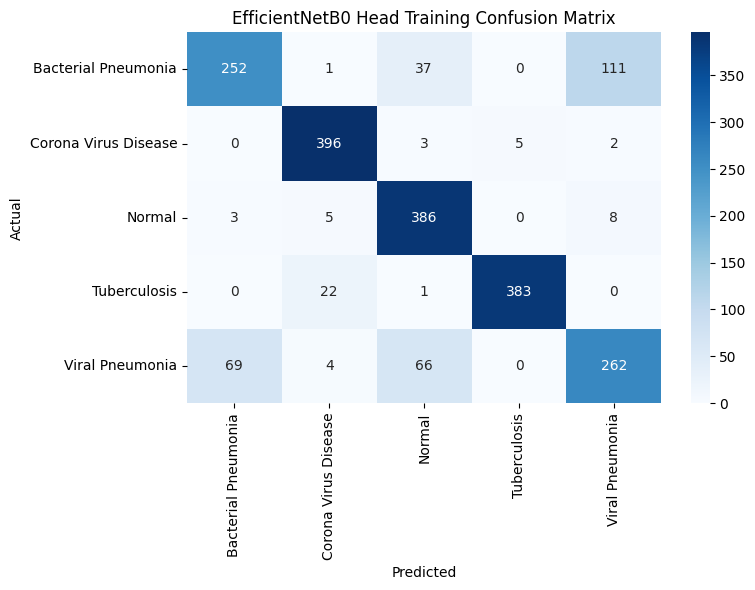

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Head Training Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "confusion_matrix.png"
    )
)

plt.show()

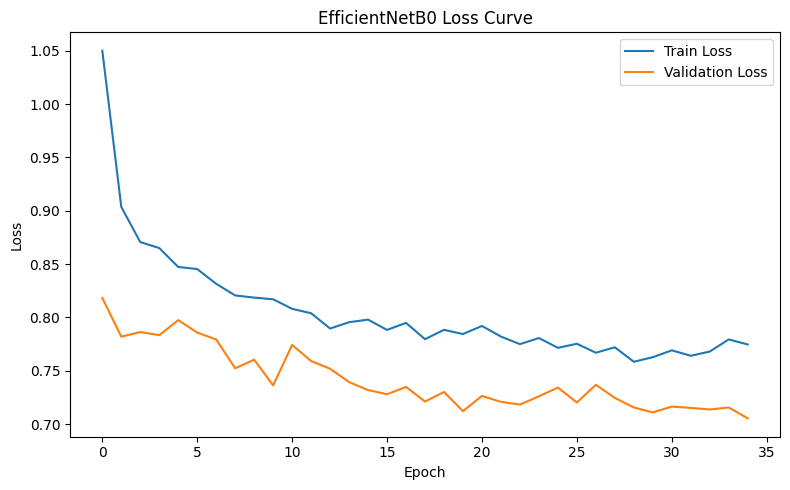

In [25]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "loss_curve.png"
    )
)

plt.show()

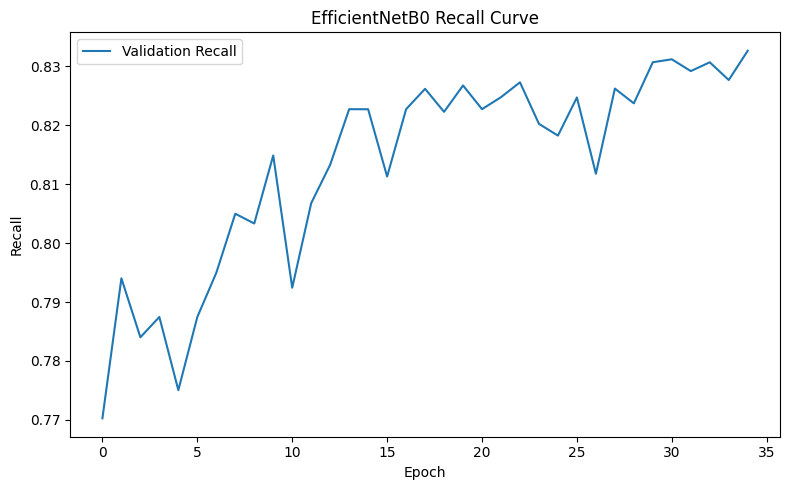

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("EfficientNetB0 Recall Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "recall_curve.png"
    )
)

plt.show()

In [27]:
best_epoch = history["val_f1"].index(
    max(history["val_f1"])
) + 1

with open(
    os.path.join(
        MODEL_DIR,
        "metrics.txt"
    ),
    "w"
) as f:

    f.write("EfficientNetB0 Head Training Results\n")
    f.write("="*50 + "\n\n")

    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best Recall: {max(history['val_recall']):.4f}\n")
    f.write(f"Best F1: {max(history['val_f1']):.4f}\n")
    f.write(f"Final Val Loss: {history['val_loss'][-1]:.4f}\n")

print("Metrics saved")

Metrics saved


In [28]:
import json

with open(
    os.path.join(
        MODEL_DIR,
        "class_names.json"
    ),
    "w"
) as f:

    json.dump(class_names, f)

print("Class names saved")

Class names saved
